# From SGD to AdamW — deriving each optimizer from the failure of the last

This notebook is for someone comfortable with **plain SGD** who wants to understand *why* the modern default optimizer is **AdamW**, not as a list of formulas but as a chain of fixes:

$$\text{SGD} \;\to\; \text{AdaGrad} \;\to\; \text{RMSProp} \;\to\; \text{Adam} \;\to\; \text{AdamW}$$

Each step exists because the previous optimizer has a **concrete, demonstrable failure**. We will:

1. Build one small neural net and a deliberately *ill-conditioned* dataset.
2. Implement every optimizer **from scratch** (so the update rule is never a black box) and verify each matches `torch.optim` to ~1e-7.
3. Run a targeted experiment that exposes the weakness motivating the next optimizer.

> The point isn't "AdamW always wins." It's understanding the specific problem each mechanism solves, so you know which knob to reach for and why.

## 0. Setup — a small net and an *ill-conditioned* problem

Adaptive optimizers earn their keep when different parameters need different step sizes. The cleanest way to create that situation is **inputs at wildly different scales**, which makes the loss surface ill-conditioned: steep in some directions, nearly flat in others.

We build a 3-feature regression where the features have standard deviations of roughly **1, 0.05, and 50** — a 1000× spread — and a smooth nonlinear target. Then a small tanh MLP.

In [1]:
import torch, math, statistics as st
import matplotlib.pyplot as plt

torch.manual_seed(0)
EPS = 1e-8  # numerical floor used by every adaptive optimizer below

def make_regression(n=2000, seed=0):
    g = torch.Generator().manual_seed(seed)
    x0 = torch.randn(n, 1, generator=g) * 1.0     # scale ~1
    x1 = torch.randn(n, 1, generator=g) * 0.05    # scale ~0.05  (tiny)
    x2 = torch.randn(n, 1, generator=g) * 50.0    # scale ~50    (huge)
    X = torch.cat([x0, x1, x2], dim=1)
    y = (torch.sin(2*x0) + 3.0*x1 + 0.01*x2
         + 0.3*x0*torch.tanh(0.02*x2)
         + 0.05*torch.randn(n, 1, generator=g))
    return X, y

def make_mlp(seed=0):
    torch.manual_seed(seed)
    return torch.nn.Sequential(
        torch.nn.Linear(3, 64), torch.nn.Tanh(),
        torch.nn.Linear(64, 64), torch.nn.Tanh(),
        torch.nn.Linear(64, 1),
    )

X, y = make_regression()
print("feature std :", [round(v,3) for v in X.std(0).tolist()])
print("target  std :", round(y.std().item(), 3))

feature std : [1.022, 0.048, 50.46]
target  std : 0.88


### Why this problem breaks a single learning rate

Feed one batch through the net and look at the **gradient magnitude of the first-layer weights, grouped by which input feature they connect to**. Because the features differ in scale by 1000×, so do their gradients.

In [2]:
m = make_mlp()
torch.nn.functional.mse_loss(m(X), y).backward()
col_rms = m[0].weight.grad.pow(2).mean(0).sqrt()  # one number per input feature
print("first-layer grad RMS per input feature:", [f"{v:.2e}" for v in col_rms.tolist()])
print(f"largest / smallest = {col_rms.max()/col_rms.min():.0f}x")

first-layer grad RMS per input feature: ['1.56e-03', '3.04e-05', '6.83e-03']
largest / smallest = 225x


A single global learning rate $\eta$ now faces an impossible tradeoff: large enough to move the **small-gradient** direction means it's far too large for the **large-gradient** direction (which diverges), and vice-versa. That tension is the seed of everything that follows.

Here is a generic full-batch training loop. We pass in an **optimizer step function** `step(params, state, lr, t)` that mutates the parameters in place — this lets us swap optimizers while holding *everything else* fixed.

In [3]:
def train(step, lr, steps=300, seed=0, data=(X, y)):
    Xd, yd = data
    model = make_mlp(seed)
    params = list(model.parameters())
    state = {}                      # per-optimizer running statistics live here
    losses = []
    for t in range(1, steps + 1):
        loss = torch.nn.functional.mse_loss(model(Xd), yd)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            step(params, state, lr, t)
        losses.append(loss.item())
    return losses

## 1. SGD — one knob for the whole network

$$\theta_{t+1} = \theta_t - \eta\, g_t, \qquad g_t = \nabla_\theta \mathcal{L}(\theta_t)$$

One scalar $\eta$ multiplies *every* coordinate of the gradient identically. Simple — and exactly the problem on an ill-conditioned surface.

In [4]:
def sgd_step(params, state, lr, t):
    for p in params:
        p -= lr * p.grad

print("SGD learning-rate sweep (final MSE after 300 steps):")
sgd_curves = {}
for lr in [3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]:
    L = train(sgd_step, lr)
    sgd_curves[lr] = L
    final = L[-1]
    bad = (not math.isfinite(final)) or final > 1e3
    print(f"  lr={lr:<7}  final MSE = {'DIVERGED' if bad else f'{final:.4f}'}")

SGD learning-rate sweep (final MSE after 300 steps):


  lr=0.0003   final MSE = 0.6026


  lr=0.001    final MSE = 0.5925


  lr=0.003    final MSE = 0.5434


  lr=0.01     final MSE = 0.4809


  lr=0.03     final MSE = 0.4947


  lr=0.1      final MSE = DIVERGED


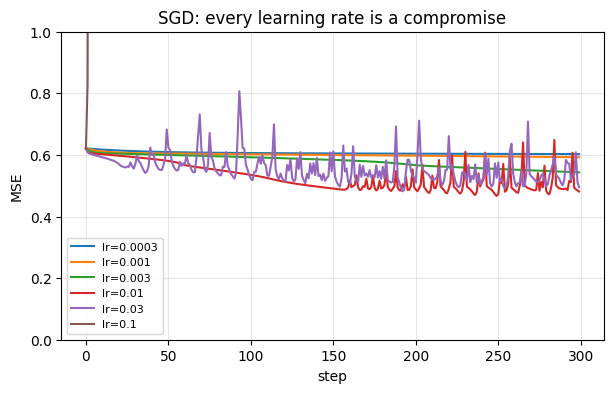

In [5]:
plt.figure(figsize=(7,4))
for lr, L in sgd_curves.items():
    Lp = [v if math.isfinite(v) and v < 1e3 else float('nan') for v in L]
    plt.plot(Lp, label=f"lr={lr}")
plt.ylim(0, 1.0); plt.xlabel("step"); plt.ylabel("MSE"); plt.title("SGD: every learning rate is a compromise")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

**Diagnosis.** The best SGD run plateaus around ~0.48 and `lr=0.1` already diverges — a narrow, mediocre stable band. There is no single $\eta$ that is simultaneously right for the steep and flat directions.

**What we want:** a *per-parameter* learning rate, set automatically from each parameter's own gradient history. That is AdaGrad.

## 2. AdaGrad — give each parameter its own rate

Idea: a parameter that has seen large gradients should take *smaller* steps; one that has seen small/rare gradients should take *larger* steps. Accumulate the sum of squared gradients per coordinate and divide by its square root:

$$G_t = G_{t-1} + g_t^2 \qquad\qquad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \varepsilon}\, g_t$$

(all operations elementwise). The denominator is large exactly in the steep directions, shrinking their effective step.

In [6]:
def adagrad_step(params, state, lr, t):
    for i, p in enumerate(params):
        G = state.get(i, torch.zeros_like(p))
        G += p.grad * p.grad            # monotonically growing accumulator
        state[i] = G
        p -= lr * p.grad / (G.sqrt() + EPS)

print(f"SGD     best of sweep : {min(L[-1] for L in sgd_curves.values()):.4f}")
print(f"AdaGrad (lr=0.1)      : {train(adagrad_step, 1e-1)[-1]:.4f}")

SGD     best of sweep : 0.4809


AdaGrad (lr=0.1)      : 0.0844


AdaGrad reaches a far lower loss with a single un-tuned-per-feature rate: the per-coordinate scaling absorbs the 1000× feature-scale spread automatically.

### The built-in flaw: the rate vanishes

$G_t$ is a **sum that only grows**. So the effective per-parameter rate $\eta/\sqrt{G_t}$ shrinks monotonically — roughly like $1/\sqrt{t}$ — and eventually approaches zero, **regardless of whether you've actually converged**. This is provably near-optimal for convex problems, but in long or non-convex deep-net training it causes the steps to die out prematurely. Let's watch it happen.

In [7]:
def track_eff_lr(step, lr, steps=1500, beta=0.9):
    '''Track the mean effective learning rate on the first weight tensor.'''
    model = make_mlp(0); params = list(model.parameters()); state = {}; eff = []
    for t in range(1, steps + 1):
        loss = torch.nn.functional.mse_loss(model(X), y); model.zero_grad(); loss.backward()
        with torch.no_grad():
            p = params[0]
            if step is adagrad_step:
                denom = (state.get(0, torch.zeros_like(p)) + p.grad**2).sqrt()
            else:  # RMSProp-style preview of the denominator
                v = state.get(0, torch.zeros_like(p)).clone().mul_(beta).addcmul_(p.grad, p.grad, value=1-beta)
                denom = v.sqrt()
            eff.append((lr / (denom + EPS)).mean().item())
            step(params, state, lr, t)
    return eff

eff_adagrad = track_eff_lr(adagrad_step, 1e-1)
print(f"AdaGrad effective LR: step 1 = {eff_adagrad[0]:.2e}   step 1500 = {eff_adagrad[-1]:.2e}")
print(f"  -> shrank by {eff_adagrad[0]/eff_adagrad[-1]:.0f}x and still falling")

AdaGrad effective LR: step 1 = 5.61e+03   step 1500 = 4.42e+01
  -> shrank by 127x and still falling


## 3. RMSProp — forget the distant past

The fix is small but decisive: replace the **infinite sum** with an **exponential moving average** (EMA) of squared gradients. Old gradients decay away, so the denominator reflects the *recent* gradient scale and stops growing without bound:

$$v_t = \beta\, v_{t-1} + (1-\beta)\, g_t^2 \qquad\qquad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t}+\varepsilon}\, g_t$$

with $\beta \approx 0.9$. Same per-parameter adaptivity as AdaGrad, but the effective rate now *stabilizes* instead of vanishing.

In [8]:
def rmsprop_step(params, state, lr, t, beta=0.9):
    for i, p in enumerate(params):
        v = state.get(i, torch.zeros_like(p))
        v.mul_(beta).addcmul_(p.grad, p.grad, value=1 - beta)   # EMA, not a running sum
        state[i] = v
        p -= lr * p.grad / (v.sqrt() + EPS)

eff_rms = track_eff_lr(rmsprop_step, 3e-3)
print(f"RMSProp effective LR: step 1 = {eff_rms[0]:.2e}   step 1500 = {eff_rms[-1]:.2e}  (stable)")

RMSProp effective LR: step 1 = 5.28e+02   step 1500 = 1.55e+03  (stable)


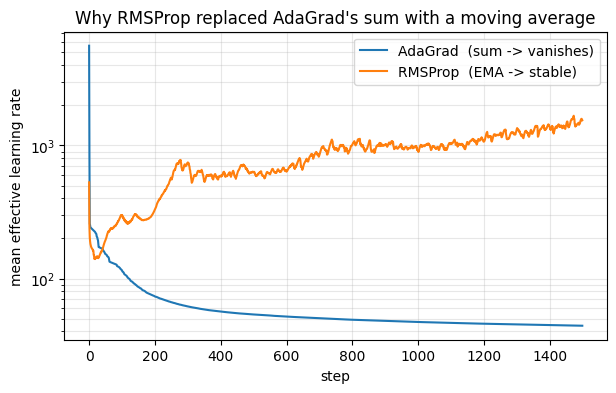

In [9]:
plt.figure(figsize=(7,4))
plt.plot(eff_adagrad, label="AdaGrad  (sum -> vanishes)")
plt.plot(eff_rms,     label="RMSProp  (EMA -> stable)")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("mean effective learning rate")
plt.title("Why RMSProp replaced AdaGrad's sum with a moving average")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

AdaGrad's effective rate decays toward zero; RMSProp's settles to a roughly constant level, so it keeps making progress on long runs.

**Remaining gap.** RMSProp scales the step well, but the *direction* it steps in is the raw, noisy current gradient $g_t$. There is no smoothing of the update direction across steps — no **momentum**. That's the last ingredient.

## 4. Adam — RMSProp + momentum + bias correction

Adam adds an EMA of the gradient itself (the **first moment**, i.e. momentum) on top of RMSProp's second moment:

$$\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1) g_t &&\text{(momentum / smoothed direction)}\\
v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2 &&\text{(scale, as in RMSProp)}
\end{aligned}$$

Both EMAs start at **zero**, so early on they are biased toward zero. Adam corrects this explicitly:

$$\hat m_t = \frac{m_t}{1-\beta_1^{\,t}}, \qquad \hat v_t = \frac{v_t}{1-\beta_2^{\,t}}, \qquad \theta_{t+1} = \theta_t - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}$$

Defaults: $\beta_1=0.9,\ \beta_2=0.999$.

In [10]:
def adam_step(params, state, lr, t, b1=0.9, b2=0.999):
    for i, p in enumerate(params):
        m, v = state.get(i, (torch.zeros_like(p), torch.zeros_like(p)))
        m.mul_(b1).add_(p.grad, alpha=1 - b1)               # 1st moment EMA
        v.mul_(b2).addcmul_(p.grad, p.grad, value=1 - b2)   # 2nd moment EMA
        state[i] = (m, v)
        mhat = m / (1 - b1**t)                               # bias correction
        vhat = v / (1 - b2**t)
        p -= lr * mhat / (vhat.sqrt() + EPS)

**Why bias correction matters.** At $t=1$, $m_1=(1-\beta_1)g_1$ — only 10% of the true gradient — so without correction the first steps are far too small. The factor $1/(1-\beta_1^t)$ is large early and $\to 1$ later. The plot shows how much it rescales the first moment over the opening steps.

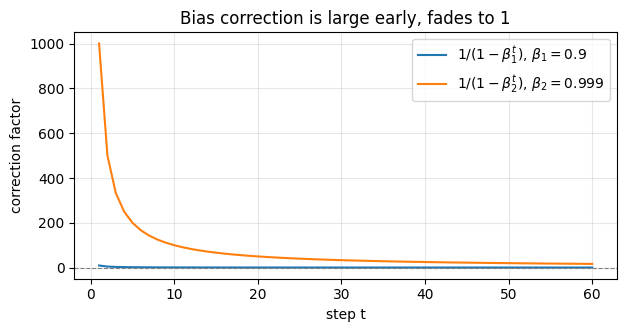

In [11]:
ts = range(1, 61)
plt.figure(figsize=(7,3.2))
plt.plot(list(ts), [1/(1-0.9**t)   for t in ts], label=r"$1/(1-\beta_1^t)$, $\beta_1=0.9$")
plt.plot(list(ts), [1/(1-0.999**t) for t in ts], label=r"$1/(1-\beta_2^t)$, $\beta_2=0.999$")
plt.axhline(1.0, color="gray", ls="--", lw=0.8)
plt.xlabel("step t"); plt.ylabel("correction factor"); plt.title("Bias correction is large early, fades to 1")
plt.legend(); plt.grid(alpha=0.3); plt.show()

RMSProp final MSE: 0.0805
Adam    final MSE: 0.0295


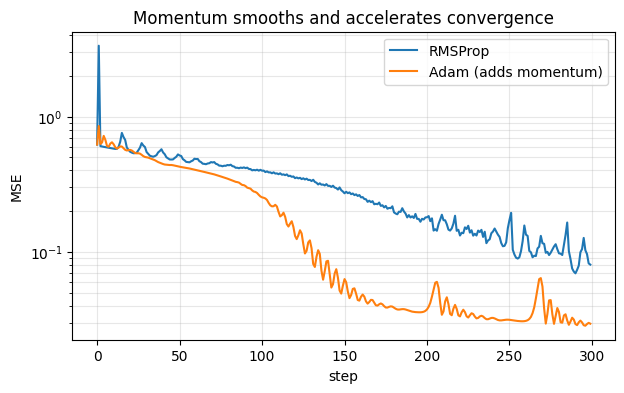

In [12]:
L_rms  = train(rmsprop_step, 3e-3)
L_adam = train(adam_step,    3e-3)
print(f"RMSProp final MSE: {L_rms[-1]:.4f}")
print(f"Adam    final MSE: {L_adam[-1]:.4f}")

plt.figure(figsize=(7,4))
plt.plot(L_rms,  label="RMSProp")
plt.plot(L_adam, label="Adam (adds momentum)")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE"); plt.title("Momentum smooths and accelerates convergence")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

Momentum gives a faster, smoother descent. Adam is the workhorse optimizer — but there's one more subtlety, and it's specifically about **regularization**.

## 5. Adam+L2 vs AdamW — decoupling weight decay

To fight overfitting we usually want **weight decay**: gently pull weights toward zero each step, $\theta \leftarrow (1-\eta\lambda)\theta$.

For plain SGD, two things are *identical*:
- adding an **L2 penalty** $\frac{\lambda}{2}\lVert\theta\rVert^2$ to the loss (which adds $\lambda\theta$ to the gradient), and
- multiplicative **weight decay** $\theta \leftarrow (1-\eta\lambda)\theta$.

**For Adam they are NOT the same.** If you add $\lambda\theta$ to the gradient, that term flows through $m_t$ and $v_t$ and gets divided by $\sqrt{\hat v_t}$:

$$\underbrace{\eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}}_{\text{step includes }\lambda\theta\text{, scaled by }1/\sqrt{\hat v_t}}$$

So the **effective decay on each weight is $\dfrac{\eta\lambda}{\sqrt{\hat v_t}+\varepsilon}$** — it depends on that weight's gradient history. Weights with large gradients get decayed *less*; the regularization is non-uniform and tangled up with the optimizer's own statistics.

**AdamW** (Loshchilov & Hutter, 2017) decouples them: run the ordinary Adam step, then apply decay **directly to the weights**, untouched by $\sqrt{\hat v_t}$:

$$\theta_{t+1} = \underbrace{(1-\eta\lambda)\,\theta_t}_{\text{uniform decay}} \;-\; \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}$$

Every weight decays at the same rate $\eta\lambda$.

In [13]:
def adam_family_step(params, state, lr, t, b1=0.9, b2=0.999, wd=0.0, decoupled=False):
    '''One function, three behaviors:
       wd=0                      -> plain Adam
       wd>0, decoupled=False     -> Adam + L2 (penalty added to gradient)
       wd>0, decoupled=True      -> AdamW   (decay applied to weights)
    '''
    for i, p in enumerate(params):
        if wd and decoupled:
            p.mul_(1 - lr * wd)                      # AdamW: decouple decay (applied first, as in torch)
        grad = p.grad + wd * p if (wd and not decoupled) else p.grad   # Adam+L2: fold into gradient
        m, v = state.get(i, (torch.zeros_like(p), torch.zeros_like(p)))
        m.mul_(b1).add_(grad, alpha=1 - b1)
        v.mul_(b2).addcmul_(grad, grad, value=1 - b2)
        state[i] = (m, v)
        mhat = m / (1 - b1**t); vhat = v / (1 - b2**t)
        p.addcdiv_(mhat, vhat.sqrt() + EPS, value=-lr)

### Sanity check: our from-scratch code equals `torch.optim`

Worth confirming the update rules are exactly what the library does (init and gradients held identical).

In [14]:
def _net(seed=0):
    torch.manual_seed(seed)
    return torch.nn.Sequential(torch.nn.Linear(8,16), torch.nn.Tanh(), torch.nn.Linear(16,1))
g = torch.Generator().manual_seed(1); Xc = torch.randn(64,8,generator=g); yc = torch.randn(64,1,generator=g)

def flat_scratch(wd, dec, steps=50):
    net = _net(); params = list(net.parameters()); state = {}
    for t in range(1, steps+1):
        torch.nn.functional.mse_loss(net(Xc), yc).backward()
        with torch.no_grad(): adam_family_step(params, state, 1e-2, t, wd=wd, decoupled=dec)
        net.zero_grad()
    return torch.cat([p.detach().flatten() for p in params])

def flat_torch(ctor, steps=50):
    net = _net(); opt = ctor(net.parameters())
    for t in range(1, steps+1):
        opt.zero_grad(); torch.nn.functional.mse_loss(net(Xc), yc).backward(); opt.step()
    return torch.cat([p.detach().flatten() for p in net.parameters()])

print("max |from-scratch - torch.optim|:")
print(f"  Adam    : {(flat_scratch(0.0,False)-flat_torch(lambda P: torch.optim.Adam(P,lr=1e-2))).abs().max():.2e}")
print(f"  Adam+L2 : {(flat_scratch(0.1,False)-flat_torch(lambda P: torch.optim.Adam(P,lr=1e-2,weight_decay=0.1))).abs().max():.2e}")
print(f"  AdamW   : {(flat_scratch(0.1,True )-flat_torch(lambda P: torch.optim.AdamW(P,lr=1e-2,weight_decay=0.1))).abs().max():.2e}")

max |from-scratch - torch.optim|:


  Adam    : 7.75e-07
  Adam+L2 : 6.71e-08
  AdamW   : 8.05e-07


### Demo 1 — Adam+L2 regularizes each weight by a *different* amount

Train with Adam, then compute the effective decay multiplier each weight *would* receive under L2, $\eta\lambda/(\sqrt{\hat v}+\varepsilon)$, across all weights. Under AdamW every weight instead gets the same $\eta\lambda$.

In [15]:
def _big(seed=0):
    torch.manual_seed(seed)
    return torch.nn.Sequential(torch.nn.Linear(20,64), torch.nn.Tanh(),
                               torch.nn.Linear(64,64), torch.nn.Tanh(), torch.nn.Linear(64,1))
g = torch.Generator().manual_seed(3); Xb = torch.randn(512,20,generator=g); yb = torch.randn(512,1,generator=g)
net = _big(); params = list(net.parameters()); state = {}; lr, wd = 1e-3, 0.05
for t in range(1, 401):
    torch.nn.functional.mse_loss(net(Xb), yb).backward()
    with torch.no_grad(): adam_family_step(params, state, lr, t)
    net.zero_grad()

vhat_all = torch.cat([(state[i][1] / (1 - 0.999**400)).flatten() for i in range(len(params))])
eff_L2 = lr * wd / (vhat_all.sqrt() + EPS)
print(f"Adam+L2 effective decay per weight: min={eff_L2.min():.2e}  median={eff_L2.median():.2e}  max={eff_L2.max():.2e}")
print(f"  -> spread of {eff_L2.max()/eff_L2.min():.0f}x across weights (NON-uniform regularization)")
print(f"AdamW  effective decay per weight: {lr*wd:.2e} for EVERY weight (uniform)")

Adam+L2 effective decay per weight: min=3.41e-03  median=8.66e-02  max=1.50e+00
  -> spread of 438x across weights (NON-uniform regularization)
AdamW  effective decay per weight: 5.00e-05 for EVERY weight (uniform)


### Demo 2 — the practical payoff: robustness to the decay strength

The coupling above has a real consequence. Because L2's $\lambda\theta$ is injected into Adam's moment estimates, a **large $\lambda$ distorts the optimization itself** and can destabilize training. AdamW's decay never touches the moments, so you can turn it up freely.

We sweep weight decay on a small, overfitting-prone classifier (150 training points, 4000-point held-out test) and compare test accuracy. Averaged over several seeds.

In [16]:
def make_class(n, d=30, seed=0):
    g = torch.Generator().manual_seed(seed)
    Xc = torch.randn(n, d, generator=g)
    w = torch.zeros(d); w[:5] = torch.tensor([2., -1.5, 1., 1.5, -2.])
    s = (Xc @ w) + 0.8*(Xc[:,0]*Xc[:,1]) - 0.5      # learnable nonlinear boundary
    return Xc, (s > 0).float().unsqueeze(1)

def clf(seed=0):
    torch.manual_seed(seed)
    return torch.nn.Sequential(torch.nn.Linear(30,128), torch.nn.ReLU(),
                               torch.nn.Linear(128,128), torch.nn.ReLU(), torch.nn.Linear(128,1))

def test_acc(use_adamw, wd, seed, epochs=400):
    Xtr, ytr = make_class(150, seed=seed); Xte, yte = make_class(4000, seed=seed+500)
    net = clf(seed); bce = torch.nn.BCEWithLogitsLoss()
    Opt = torch.optim.AdamW if use_adamw else torch.optim.Adam
    opt = Opt(net.parameters(), lr=3e-3, weight_decay=wd)
    for _ in range(epochs):
        opt.zero_grad(); bce(net(Xtr), ytr).backward(); opt.step()
    with torch.no_grad():
        return ((net(Xte) > 0).float() == yte).float().mean().item()

wds = [0.0, 0.03, 0.1, 0.3, 1.0, 3.0]
seeds = range(5)
l2_acc    = [st.mean([test_acc(False, wd, s) for s in seeds]) for wd in wds]
adamw_acc = [st.mean([test_acc(True,  wd, s) for s in seeds]) for wd in wds]
print("wd      Adam+L2   AdamW")
for wd, a, b in zip(wds, l2_acc, adamw_acc):
    print(f"{wd:<6}  {a:.3f}     {b:.3f}")

wd      Adam+L2   AdamW
0.0     0.862     0.862
0.03    0.889     0.862
0.1     0.887     0.862
0.3     0.510     0.861
1.0     0.510     0.861
3.0     0.510     0.859


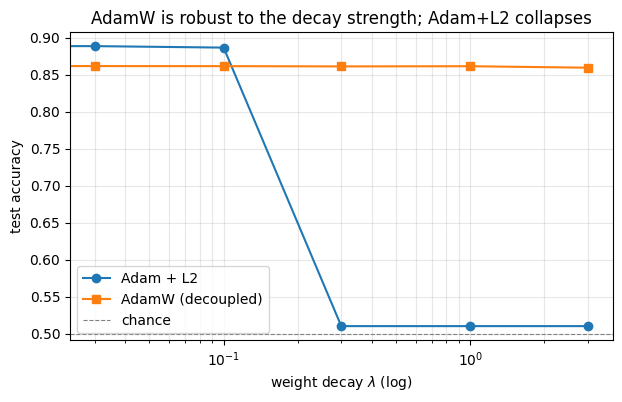

In [17]:
plt.figure(figsize=(7,4))
plt.plot(wds, l2_acc,    "o-", label="Adam + L2")
plt.plot(wds, adamw_acc, "s-", label="AdamW (decoupled)")
plt.axhline(0.5, color="gray", ls="--", lw=0.8, label="chance")
plt.xscale("log"); plt.xlabel("weight decay $\\lambda$ (log)"); plt.ylabel("test accuracy")
plt.title("AdamW is robust to the decay strength; Adam+L2 collapses")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

**Read this honestly.** At its *best* $\lambda$, Adam+L2 can match or slightly beat AdamW on a toy like this. But notice what happens as $\lambda$ grows: Adam+L2 has a narrow sweet spot and then **falls off a cliff to chance** once the injected penalty destabilizes the moments, while **AdamW stays flat across the entire range**.

That decoupling buys two things that matter in practice:
- **Uniform regularization** — every weight decays at the same rate, independent of its gradient history (Demo 1).
- **Decoupled hyperparameters** — the right weight decay no longer depends on the learning rate, so the two can be tuned independently and aggressively. On real networks (notably Transformers) this is why AdamW also tends to *generalize* better, not merely more robustly.

This is why `AdamW` is the default optimizer in modern deep-learning stacks.

## 6. The chain, in one view

| Optimizer | Update (elementwise) | What it fixed | What still hurt |
|---|---|---|---|
| **SGD** | $\theta -\eta g$ | — | one global rate can't fit ill-conditioned surfaces |
| **AdaGrad** | $\theta - \dfrac{\eta}{\sqrt{G}+\varepsilon} g,\ \ G\mathrel{+}=g^2$ | per-parameter rates; handles scale & sparsity | $G$ only grows → effective rate **vanishes** |
| **RMSProp** | $\theta - \dfrac{\eta}{\sqrt{v}+\varepsilon} g,\ \ v=\beta v+(1-\beta)g^2$ | EMA forgets old grads → rate **stays alive** | steps follow the raw, noisy gradient (no momentum) |
| **Adam** | $\theta - \eta\dfrac{\hat m}{\sqrt{\hat v}+\varepsilon}$ | momentum + bias correction → fast, smooth | L2 regularization gets **entangled** with $\sqrt{\hat v}$ |
| **AdamW** | $(1-\eta\lambda)\theta - \eta\dfrac{\hat m}{\sqrt{\hat v}+\varepsilon}$ | **decoupled** weight decay: uniform & robust | (current default) |

### Practical defaults
- **Reach for AdamW first** for most deep nets (Transformers, most things you train from scratch). Typical start: `lr=3e-4`, `betas=(0.9, 0.999)`, `eps=1e-8`, `weight_decay≈0.01–0.1`.
- **Use the `weight_decay` argument of `AdamW`, not `Adam`** — `torch.optim.Adam(..., weight_decay=)` is the *coupled* L2 form this notebook warns about.
- **Don't decay everything**: it's common to exclude biases and normalization (LayerNorm/BatchNorm) parameters from weight decay.
- **SGD + momentum still wins sometimes** — notably some convolutional vision models — where it can reach better final generalization than adaptive methods, at the cost of more LR tuning.
- **The intuition to keep**: *AdaGrad/RMSProp* answer "how big a step per parameter?", *Adam* adds "in which smoothed direction?", and *AdamW* fixes "how do we regularize without corrupting those answers?"
